# Medium access and interference

> When many agents talk at once, who is heard? Protocols compared as the number of agents grows.

Every agent has a message for every other agent at every step, e.g. its latest state. The agents stand 5 m apart
on a line and share one radio channel (`InterferenceBackend`). A message is received if its SINR is at least
10 dB, and radios are half-duplex, so a node that transmits cannot receive at the same time.

Three protocols:

* `IdealProtocol`: everyone transmits at every step.
* `TDMAProtocol`: the agents take turns, one per step.
* `SlottedALOHA`: each agent transmits with probability `1/N`, without coordination.

Every agent keeps only its newest round of messages (`queue_size`), since older states are stale. Two quantities
are measured:

* **Throughput:** how many messages an agent receives per step.
* **Age of information:** at every step, how old the newest message it has from each other agent is, in steps
  since that message was written.

In [ ]:
import math

import matplotlib.pyplot as plt
import numpy as np

from comm_core import *

In [ ]:
class PathLoss(Fading):
    "Log-distance path loss with Rayleigh fading: |h|^2 = gain_1m / d^exponent x |CN(0, 1)|^2, from the nodes' positions."

    def __init__(self, exponent=3.0, gain_1m=1e-4, rayleigh=True, seed=None):
        self.exponent, self.gain_1m, self.rayleigh = exponent, gain_1m, rayleigh
        self.positions, self.rng = {}, np.random.default_rng(seed)

    def set_positions(self, positions):
        self.positions.update({k: np.asarray(v, float) for k, v in positions.items()})

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)

    def coefficient(self, transmission, link):
        d = max(np.linalg.norm(self.positions[transmission.sender] - self.positions[transmission.receiver]), 0.1)
        h = math.sqrt(self.gain_1m / d ** self.exponent)
        if self.rayleigh:
            h *= complex(self.rng.standard_normal(), self.rng.standard_normal()) / math.sqrt(2)
        return h

In [ ]:
def simulate(protocol_name, n, steps=200, seed=0):
    nodes = [f'n{i}' for i in range(n)]
    fading = PathLoss(exponent=3.0, gain_1m=1e-4, rayleigh=False)
    fading.set_positions({a: (5.0 * i, 0.0) for i, a in enumerate(nodes)})
    channel = SystemLevelChannel(fading=fading, noise_power=10 ** ((-94 - 30) / 10), per_model='threshold', snr_threshold_db=10)
    protocol = {'IdealProtocol': lambda: IdealProtocol(),
                'TDMAProtocol': lambda: TDMAProtocol(nodes, queue_size=n - 1),
                'SlottedALOHA': lambda: SlottedALOHA(p=1 / n, queue_size=n - 1, seed=seed)}[protocol_name]()
    topology = FullMeshTopology(nodes)
    for s in nodes:
        for r in nodes:
            if s != r:
                topology.get_link(s, r).tx_power_w = 1e-3                     # 1 mW
    net = Network([Node(a) for a in nodes], topology, protocol, InterferenceBackend(channel))
    net.reset(seed)
    received, newest, ages = 0, {}, []
    for step in range(steps):
        for s in nodes:
            for r in nodes:
                if s != r:
                    net.send(Message(s, r, payload=None, size_bits=256, timestamp=net.time))
        net.step()
        for a in nodes:
            for m in net.receive(a):
                received += 1
                newest[a, m.sender] = max(newest.get((a, m.sender), -1.0), m.timestamp)
        if step >= steps // 2:                                         # once settled: the age of what each agent knows
            ages += [net.time - written for written in newest.values()]
    return received / (steps * n), (np.mean(ages) if ages else np.nan)

sizes = range(2, 11)
table = {p: [simulate(p, n) for n in sizes] for p in ('IdealProtocol', 'TDMAProtocol', 'SlottedALOHA')}
print(' N  ' + ''.join(f'{p:>30s}' for p in table))
for i, n in enumerate(sizes):
    print(f'{n:2d}  ' + ''.join(f'{table[p][i][0]:15.2f} msgs, age {table[p][i][1]:5.1f}' for p in table))

 N                   IdealProtocol                  TDMAProtocol                  SlottedALOHA
 2             0.00 msgs, age   nan           0.50 msgs, age   1.5           0.22 msgs, age   4.5
 3             0.00 msgs, age   nan           0.67 msgs, age   2.0           0.29 msgs, age   7.6
 4             0.00 msgs, age   nan           0.75 msgs, age   2.5           0.36 msgs, age   8.4
 5             0.00 msgs, age   nan           0.80 msgs, age   3.0           0.39 msgs, age   9.4
 6             0.00 msgs, age   nan           0.83 msgs, age   3.5           0.38 msgs, age  15.1
 7             0.00 msgs, age   nan           0.82 msgs, age   4.0           0.39 msgs, age  13.4
 8             0.00 msgs, age   nan           0.78 msgs, age   4.5           0.42 msgs, age  15.0
 9             0.00 msgs, age   nan           0.74 msgs, age   5.0           0.38 msgs, age  17.7
10             0.00 msgs, age   nan           0.70 msgs, age   5.5           0.38 msgs, age  15.9


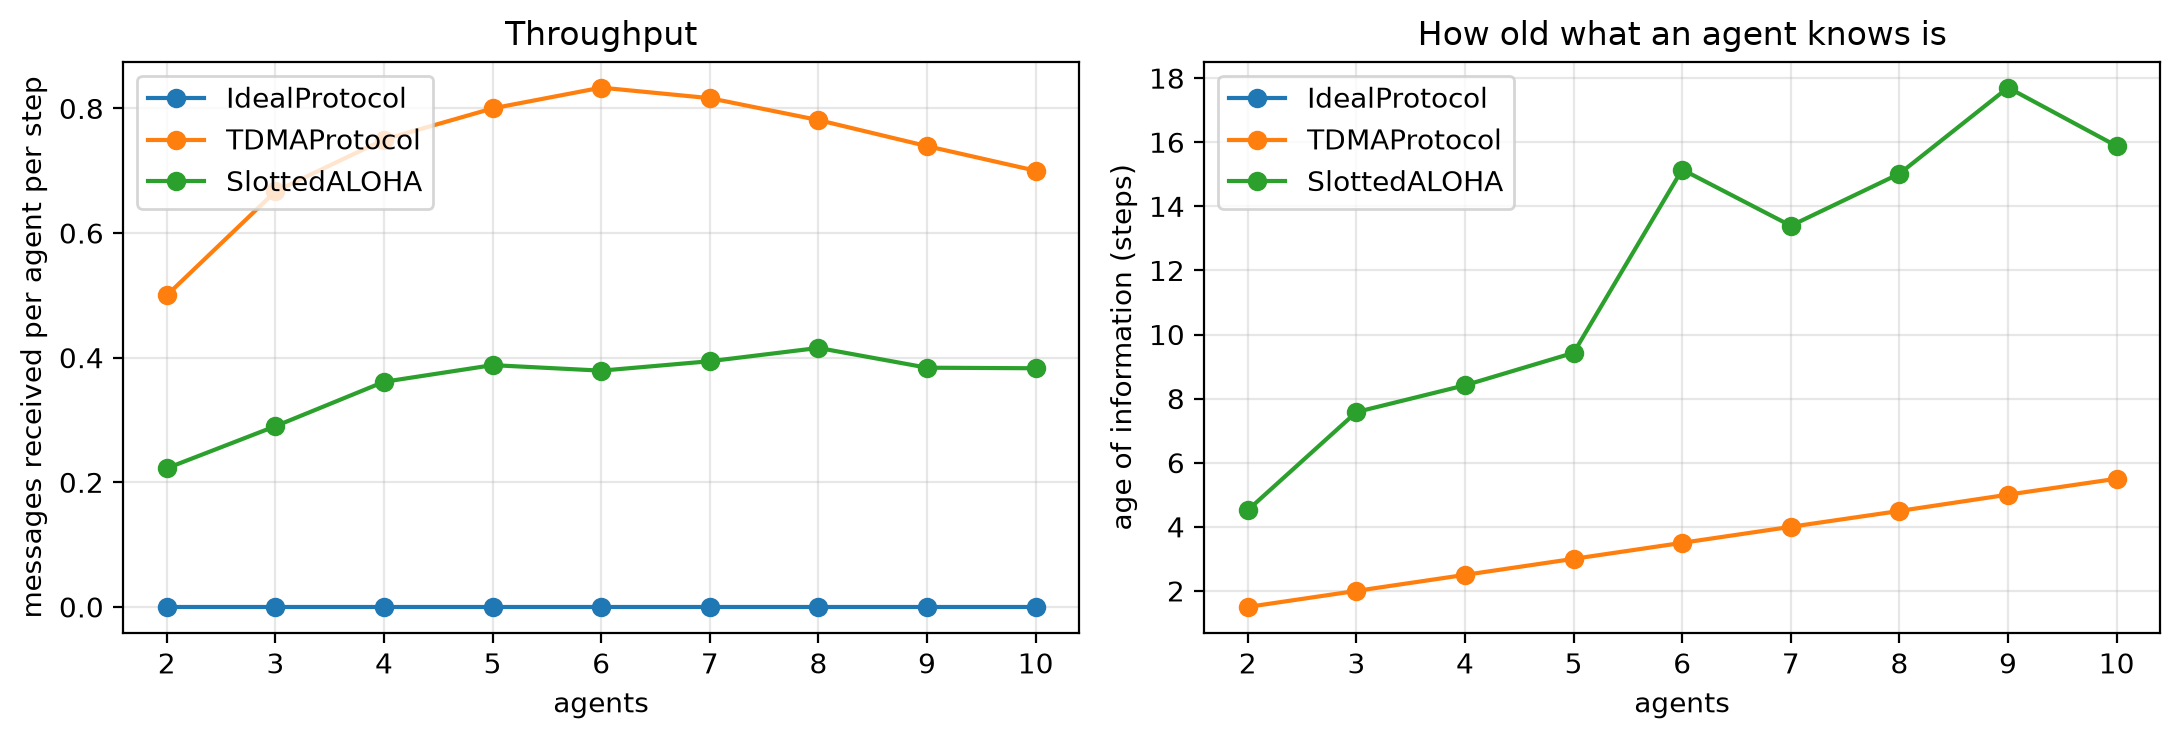

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for p, rows in table.items():
    axes[0].plot(list(sizes), [r[0] for r in rows], 'o-', label=p)
    axes[1].plot(list(sizes), [r[1] for r in rows], 'o-', label=p)
axes[0].set(xlabel='agents', ylabel='messages received per agent per step', title='Throughput')
axes[1].set(xlabel='agents', ylabel='age of information (steps)', title='How old what an agent knows is')
for ax in axes:
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()

* **`IdealProtocol`:** nobody hears anything, since everyone is transmitting at once.
* **`TDMAProtocol`:** one agent is heard per step, however many there are, so each agent's news of another comes
  once per frame. The age of information grows with the number of agents: the more agents, the staler what each
  knows of the others. Far agents can also be out of range of a single sender, so they hear less.
* **`SlottedALOHA`:** in between. Collisions waste some steps, but there is no fixed waiting time.

For a learning method, these are the conditions it has to cope with: messages that arrive late, or not at all,
depending on how many agents share the channel.

In [ ]:
assert all(r[0] == 0 for r in table['IdealProtocol'])
assert all(r[0] > 0 for r in table['TDMAProtocol']) and table['TDMAProtocol'][-1][1] > table['TDMAProtocol'][0][1] + 2